In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Carisurg_Triage_Test/EmergencyTriageDataset_Reduced_Dirty.csv')

In [4]:
print(df['Gender'].unique())

['0' 'Male' 'Female' 'FEMALE' '1' 'MALE']


In [5]:
print(df['Gender'].value_counts())

Gender
1         422
MALE      379
Male      375
FEMALE    366
Female    340
0         323
Name: count, dtype: int64


In [6]:
gender_mapping = {
    '1': 1, 'Male': 1, 'MALE': 1,
    '0': 0, 'Female': 0, 'FEMALE': 0,
}

In [7]:
df['Gender'] = df['Gender'].map(gender_mapping)
print("NaN after mapping:", df['Gender'].isna().sum())

NaN after mapping: 0


In [8]:
print(df['Gender'].value_counts())

Gender
1    1176
0    1029
Name: count, dtype: int64


In [9]:
df = df.rename(columns={'Gender': 'Gender_clean'})
display(df[['Gender_clean']].head())

,Gender_clean
0,0
1,1
2,0
3,0
4,0


In [10]:
print("Data type:", df['DBP'].dtype)
print(df['DBP'].describe())
print("Unique value count:", df['DBP'].nunique())
print(df['DBP'].value_counts().sort_index().head(20))

Data type: float64
count    2183.000000
mean       77.479615
std        16.713289
min        30.000000
25%        70.000000
50%        78.000000
75%        87.000000
max       173.000000
Name: DBP, dtype: float64
Unique value count: 96
DBP
30.0     1
32.0     1
35.0     2
36.0     2
37.0     1
39.0     1
40.0    16
42.0     2
44.0     5
45.0    11
47.0     4
48.0     4
49.0     2
50.0    66
51.0     4
52.0     4
53.0     9
54.0     5
55.0    29
56.0     7
Name: count, dtype: int64


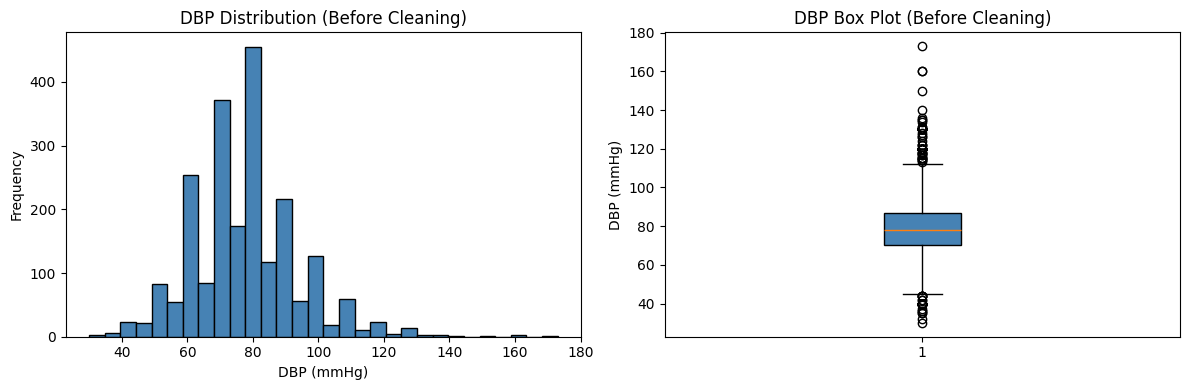

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df['DBP'], bins=30, color='steelblue', edgecolor='black')
ax1.set_title('DBP Distribution (Before Cleaning)')
ax1.set_xlabel('DBP (mmHg)')
ax1.set_ylabel('Frequency')
ax2.boxplot(df['DBP'].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black'))
ax2.set_title('DBP Box Plot (Before Cleaning)')
ax2.set_ylabel('DBP (mmHg)')
plt.tight_layout()
plt.show()

In [12]:
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
print("Data type after conversion:", df['DBP'].dtype)
print("NaN count after conversion:", df['DBP'].isna().sum())

Data type after conversion: float64
NaN count after conversion: 22


In [13]:
lower_bound = 30
upper_bound = 150
df.loc[df['DBP'] < lower_bound, 'DBP'] = float('nan')
df.loc[df['DBP'] > upper_bound, 'DBP'] = float('nan')
print(f"Values below {lower_bound} or above {upper_bound} replaced with NaN")
print("NaN count after range filter:", df['DBP'].isna().sum())

Values below 30 or above 150 replaced with NaN
NaN count after range filter: 25


In [14]:
dbp_median = df['DBP'].median()
print("Median DBP:", dbp_median)
df['DBP'] = df['DBP'].fillna(dbp_median)
print("NaN count after imputation:", df['DBP'].isna().sum())

Median DBP: 78.0
NaN count after imputation: 0


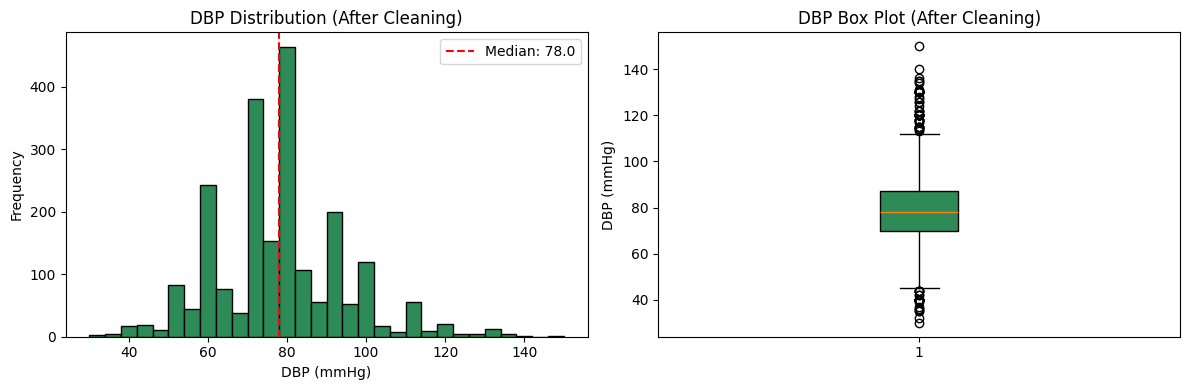

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df['DBP'], bins=30, color='seagreen', edgecolor='black')
ax1.axvline(dbp_median, color='red', linestyle='--', label=f'Median: {dbp_median}')
ax1.set_title('DBP Distribution (After Cleaning)')
ax1.set_xlabel('DBP (mmHg)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax2.boxplot(df['DBP'].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='seagreen', color='black'))
ax2.set_title('DBP Box Plot (After Cleaning)')
ax2.set_ylabel('DBP (mmHg)')
plt.tight_layout()
plt.show()

In [16]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,ID,Age,Gender_clean,DBP,MAP,RR,Fio2
count,2205.000000,2205.000000,2205.000000,2205.000000,2183.000000,2183.000000,2183.000000
mean,1154.987755,61.829478,0.533333,77.367347,93.912277,20.262254,25.019698
std,677.167364,18.485363,0.499001,16.316160,19.006296,5.742333,10.144288
min,1.000000,18.000000,0.000000,30.000000,39.330000,12.000000,21.000000
25%,577.000000,50.000000,0.000000,70.000000,82.500000,17.000000,21.000000
50%,1135.000000,64.000000,1.000000,78.000000,93.330000,18.000000,21.000000
75%,1703.000000,77.000000,1.000000,87.000000,103.330000,21.000000,21.000000
max,2384.000000,98.000000,1.000000,150.000000,185.000000,50.000000,100.000000


In [21]:
print("\nKey Observations:")
print(f"  - Average Age    : {pd.to_numeric(df['Age'], errors='coerce').mean():.1f} years")
print(f"  - Average DBP    : {df['DBP'].mean():.1f} mmHg")
print(f"  - Average Pulse  : {pd.to_numeric(df['pulse'], errors='coerce').mean():.1f} bpm")
print(f"  - Average Temp   : {pd.to_numeric(df['Temp'], errors='coerce').mean():.1f} °C")
print(f"  - Gender balance : Male = {(df['Gender_clean'] == 1).sum()}, Female = {(df['Gender_clean'] == 0).sum()}")


Key Observations:
  - Average Age    : 61.8 years
  - Average DBP    : 77.4 mmHg
  - Average Pulse  : 96.1 bpm
  - Average Temp   : 37.3 °C
  - Gender balance : Male = 1176, Female = 1029


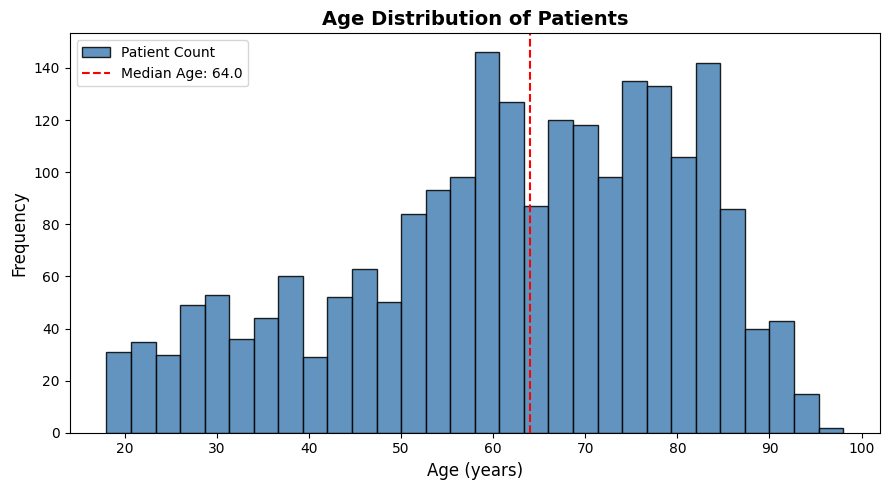

In [22]:
age_median = df['Age'].median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Age'], bins=30, color='steelblue',
        edgecolor='black', alpha=0.85, label='Patient Count')
ax.axvline(age_median, color='red', linestyle='--',
           linewidth=1.5, label=f'Median Age: {age_median:.1f}')
ax.set_title('Age Distribution of Patients', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
male   = df[df['Gender_clean'] == 1]
female = df[df['Gender_clean'] == 0]

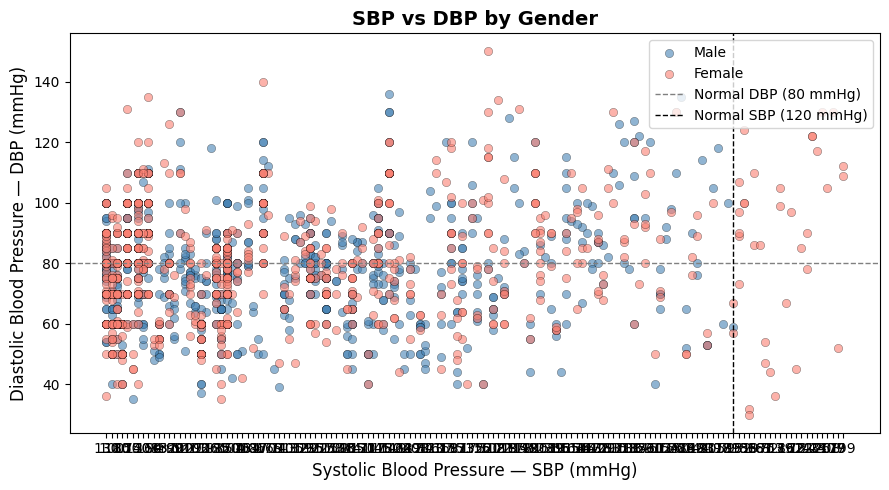

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(male['SBP'], male['DBP'], color='steelblue', alpha=0.6,
           label='Male', edgecolors='black', linewidths=0.3)
ax.scatter(female['SBP'], female['DBP'], color='salmon', alpha=0.6,
           label='Female', edgecolors='black', linewidths=0.3)
ax.axhline(80, color='gray', linestyle='--',
           linewidth=1, label='Normal DBP (80 mmHg)')
ax.axvline(120, color='black', linestyle='--',
           linewidth=1, label='Normal SBP (120 mmHg)')
ax.set_title('SBP vs DBP by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Systolic Blood Pressure — SBP (mmHg)', fontsize=12)
ax.set_ylabel('Diastolic Blood Pressure — DBP (mmHg)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
print("Final Dataset Shape:", df.shape)
print("\nRemaining NaN values:")
print(df.isna().sum())
display(df.head(10))

Final Dataset Shape: (2205, 11)

Remaining NaN values:
ID               0
Age              0
Gender_clean     0
GCS             22
SBP              0
DBP              0
MAP             22
pulse           22
Temp            22
RR              22
Fio2            22
dtype: int64


,ID,Age,Gender_clean,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,1,15.0,100,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,0,15.0,120,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,1,15.0,100,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,0,15.0,153,82.0,105.67,130.0,37.0,19.0,21.0
